In [81]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import lambertw
from math import ceil
from matplotlib.lines import Line2D


In [82]:
def legend_rowwise(ncol, **legend_kwargs):
    ax = plt.gca()
    handles, labels = ax.get_legend_handles_labels()
    m = len(handles)
    rows = ceil(m / ncol)

    # pad to full grid so indexing is easy
    pad = rows * ncol - m
    if pad:
        blank = Line2D([], [], linestyle='None', alpha=0)
        handles += [blank] * pad
        labels  += [''] * pad

    # build row-major grid of indices
    idx = list(range(len(handles)))
    grid = [idx[r*ncol:(r+1)*ncol] for r in range(rows)]

    # legend consumes column-major; feed it in that order
    order = [grid[r][c] for c in range(ncol) for r in range(rows)]
    handles = [handles[i] for i in order]
    labels  = [labels[i]  for i in order]

    plt.legend(handles, labels, ncol=ncol, **legend_kwargs)

In [83]:
def mse_ratio(c, q):
    num = (c+1)*(q+1)**2
    denom = (q+c+1) * (q*c+q+1)
    return num / denom

In [92]:
mse_ratio(512, 1)

0.007766960892670593

In [85]:
mi_range = [2**(x) for x in [-10, -8, -6, -4, -2]]
labels = ['$2^{-10}$', '$2^{-8}$', '$2^{-6}$', '$2^{-4}$', '$2^{-2}$']
c_range = [1/(2*mi) for mi in mi_range]
snr_range = [x/1000 for x in range(1, 10000)]

In [86]:
mi_range, c_range

([0.0009765625, 0.00390625, 0.015625, 0.0625, 0.25],
 [512.0, 128.0, 32.0, 8.0, 2.0])

In [87]:
from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
# plt.rcParams["font.family"] = "Helvetica"
rc = {"font.family" : "serif", 
      "mathtext.fontset" : "stix"}
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

# rc('text', usetex=False)

512.0 0.6622597797656864
128.0 0.8875050776001768
32.0 0.9699618947274117
8.0 0.9929531010154249
2.0 0.9986710976700021


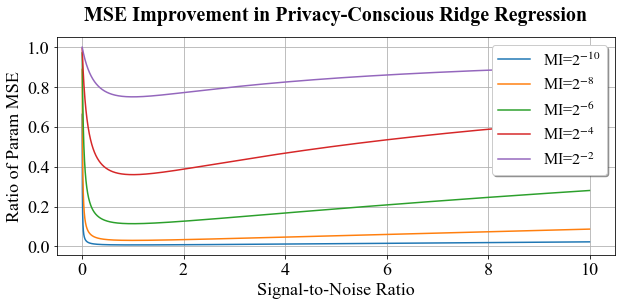

In [90]:
fig, axes = plt.subplots(1, figsize=(10, 4))
for ind, c in enumerate(c_range):
    xs, ys = [], []
    for snr in snr_range:
        xs.append(snr)
        ys.append(mse_ratio(c, snr))
    print(c, max(ys))
    plt.plot(xs, ys, label=f'MI={labels[ind]}')
# plt.legend(fontsize=16)
# handles, labels = plt.gca().get_legend_handles_labels()
# handles = handles[::2] + handles[1::2]
# labels  = labels[::2]  + labels[1::2]
leg = plt.legend(
    fontsize=16,
    loc='upper right',
#     bbox_to_anchor=(0.48, -0.2),
    ncol=1,
    fancybox=True,
    shadow=True,
    frameon=True
)

axes.grid(True)
axes.tick_params(axis='both', labelsize=18)
plt.xlabel("Signal-to-Noise Ratio", fontsize=18)
plt.ylabel("Ratio of Param MSE", fontsize=18)
plt.title("MSE Improvement in Privacy-Conscious Ridge Regression", fontsize=20, fontweight="bold", y=1.05)
plt.savefig('../figs/snr_to_mse.pdf',  bbox_inches = "tight")

In [8]:
1/mse_ratio(512, 1)

128.7504873294347

$$\eta_B^* =\frac{1}{\alpha}\big[\frac{\alpha e_0^2}{\beta} + 1 - W(e^{ \frac{\alpha e_0^2}{\beta} + 1})\big],$$
$$\alpha= \mu T$$
$$\beta = \frac{(1+C)\sigma^2}{\mu}$$
$$MSE = (1-\eta \mu)^T e_0^2 + \frac{\eta}{\mu} (C+1) \sigma^2(1-(1-\eta\mu)^T)$$

In [9]:

def solve_for_optimal_eta(mu, sigma_sq, e_0, C, T=32):
    alpha = mu*T
    beta = (1+C) * sigma_sq / mu
    coef = 1./alpha
    first = alpha*e_0**2 / beta
    lambert = lambertw(np.exp(first + 1))
    return coef*(first + 1 - lambert)

def mse_gd(eta, mu, e_0, C, sigma_sq, T=32):
    bias = (1-eta*mu)**T * e_0**2
    var = (eta / mu)*(C+1)*sigma_sq * (1-(1-eta*mu)**T)
    return bias + var

(0.0005159610956174661+0j)
(0.002060528179101338+0j)
(0.00818946370835119+0j)
(0.03194095508635159+0j)
(0.11614682654521985+0j)


/opt/homebrew/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(0.003136828857757057+0j)
(0.012365389760193763+0j)
(0.04674797041681213+0j)
(0.1534027128122243+0j)
(0.3631479429376422+0j)


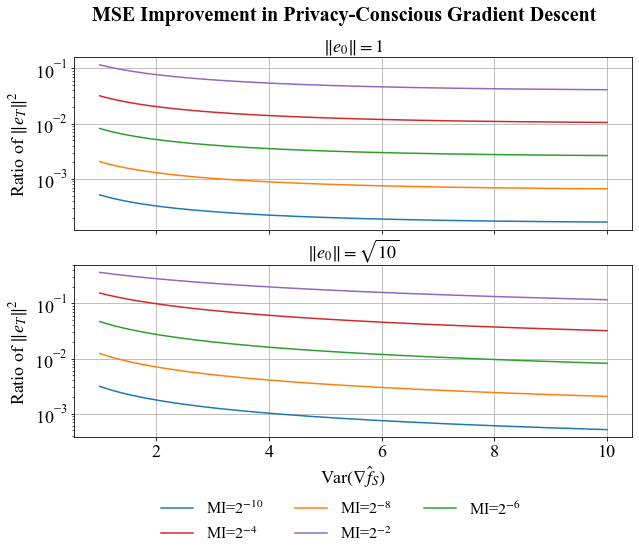

In [93]:

def solve_for_optimal_eta(mu, sigma_sq, e_0, C, T=50):
    alpha = mu*T
    beta = (1+C) * sigma_sq / mu
    coef = 1./alpha
    first = alpha*e_0**2 / beta
    lambert = lambertw(np.exp(first + 1))
    return coef*(first + 1 - lambert)

def mse_gd(eta, mu, e_0, C, sigma_sq, T=50):
    bias = (1-eta*mu)**T * e_0**2
    var = (eta / mu)*(C+1)*sigma_sq * (1-(1-eta*mu)**T)
    return bias + var

mu = 1
L = 1
T=50

mi_range = [2**(x) for x in [-10, -8, -6, -4, -2]]
labels = ['$2^{-10}$', '$2^{-8}$', '$2^{-6}$', '$2^{-4}$', '$2^{-2}$']
c_range = [1/(2*mi) for mi in mi_range]
fig, axes = plt.subplots(2, figsize=(10, 7), sharex=True)
es = [1, 10**0.5]
titles = [r"$\Vert e_0 \Vert =1$", r"$\Vert e_0 \Vert = \sqrt{10}$"]
for e_ind, ax in enumerate(axes):
    e_0 = es[e_ind]

    for ind,C in enumerate(c_range):
        C*=T # per epoch vs. overall

        xs = []
        ys = []
        for sigma_sq in [x/1000 for x in range(1000, 10000)]:
            step_size_default = solve_for_optimal_eta(mu=mu, sigma_sq=sigma_sq, e_0=e_0, C=0, T=T)

            optimal_eta = solve_for_optimal_eta(mu=mu, sigma_sq=sigma_sq, e_0=e_0, C=C, T=T)
            if np.isinf(optimal_eta):
                continue
            optimal_mse = mse_gd(optimal_eta, mu, e_0, C, sigma_sq, T=T)
            default_mse = mse_gd(step_size_default, mu, e_0, C, sigma_sq, T=T)
            xs.append(sigma_sq)
            ys.append(optimal_mse/default_mse)
        print(max(ys))
        ax.plot(xs, ys, label=f'MI={labels[ind]}')
    ax.grid(True)
    ax.tick_params(axis='both', labelsize=18)
    ax.set_ylabel("Ratio of $\Vert e_T \Vert^2$", fontsize=18)
    ax.set_yscale('log')

    ax.set_title(titles[e_ind], fontsize=18)
ax.set_xlabel(r"$\mathdefault{Var}(\nabla \hat{f}_S)$", fontsize=18)

plt.subplots_adjust(hspace=0.2)
handles, labels = ax.get_legend_handles_labels()


legend_rowwise(3, loc=2, bbox_to_anchor=(0.13, -0.28), prop={'size': 16}, frameon=False)

# lgd = fig.legend(handles, labels, ncol=3, loc=2, prop={'size': 16}, bbox_to_anchor=(0.24, 0.01), frameon=False)
plt.suptitle("MSE Improvement in Privacy-Conscious Gradient Descent", fontsize=20, fontweight="bold")
plt.savefig('../figs/sigma_sq_to_mse.pdf',  bbox_inches = "tight")

In [18]:
labels

['MI=$2^{-10}$', 'MI=$2^{-6}$', 'MI=$2^{-2}$', 'MI=$2^{-8}$', 'MI=$2^{-4}$']

In [36]:
e_0=1
sigma_sq = 1
mu = 1
mi = 1/64
C = 1/(2*mi)
C*=T # per epoch vs. overall
step_size_default = solve_for_optimal_eta(mu=mu, sigma_sq=sigma_sq, e_0=e_0, C=0, T=50)

optimal_eta = solve_for_optimal_eta(mu=mu, sigma_sq=sigma_sq, e_0=e_0, C=C, T=50)
optimal_mse = mse_gd(optimal_eta, mu, e_0, C, sigma_sq, T=50)
default_mse = mse_gd(step_size_default, mu, e_0, C, sigma_sq, T=50)
print(optimal_mse/default_mse)

(122.10811789546756+0j)


In [31]:
1./0.3631479429376422

2.7536986494006235